In [5]:

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
    

In [6]:

# Load your datasets
customer_df = pd.read_csv(r"C:\Users\khush\Desktop\K - Projects\BGC group\Data Science\Task files'\customer_data.csv")
pricing_df = pd.read_csv(r"C:\Users\khush\Desktop\K - Projects\BGC group\Data Science\Task files'\pricing_data.csv")
    

In [ ]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  int32         
 1   channel_sales                   14606 non-null  int32         
 2   cons_12m                        14606 non-null  float64       
 3   cons_gas_12m                    14606 non-null  float64       
 4   cons_last_month                 14606 non-null  float64       
 5   date_activ                      14606 non-null  datetime64[ns]
 6   date_end                        14606 non-null  datetime64[ns]
 7   date_modif_prod                 14606 non-null  datetime64[ns]
 8   date_renewal                    14606 non-null  datetime64[ns]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  float64       
 11  fo

In [18]:
pricing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  193002 non-null  object        
 1   price_date          193002 non-null  datetime64[ns]
 2   price_off_peak_var  193002 non-null  float64       
 3   price_peak_var      193002 non-null  float64       
 4   price_mid_peak_var  193002 non-null  float64       
 5   price_off_peak_fix  193002 non-null  float64       
 6   price_peak_fix      193002 non-null  float64       
 7   price_mid_peak_fix  193002 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 11.8+ MB


In [7]:

# Convert date columns
customer_df['date_activ'] = pd.to_datetime(customer_df['date_activ'], errors='coerce')
customer_df['date_end'] = pd.to_datetime(customer_df['date_end'], errors='coerce')
customer_df['date_modif_prod'] = pd.to_datetime(customer_df['date_modif_prod'], errors='coerce')
customer_df['date_renewal'] = pd.to_datetime(customer_df['date_renewal'], errors='coerce')
pricing_df['price_date'] = pd.to_datetime(pricing_df['price_date'], errors='coerce')
    

In [8]:

# Convert 'has_gas' to boolean
customer_df['has_gas'] = customer_df['has_gas'].map({'t': True, 'f': False})

# Replace "MISSING" with NaN
customer_df.replace("MISSING", pd.NA, inplace=True)
    

In [9]:

# Handle missing values
num_cols = customer_df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = customer_df.select_dtypes(include=['object', 'bool']).columns

# Replace pd.NA with np.nan for compatibility with imputers
customer_df[num_cols] = customer_df[num_cols].replace({pd.NA: None})
customer_df[cat_cols] = customer_df[cat_cols].replace({pd.NA: None})

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

customer_df[num_cols] = imputer_num.fit_transform(customer_df[num_cols])
customer_df[cat_cols] = imputer_cat.fit_transform(customer_df[cat_cols])
    

In [10]:

# Label encode categorical features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    customer_df[col] = le.fit_transform(customer_df[col])
    label_encoders[col] = le
    

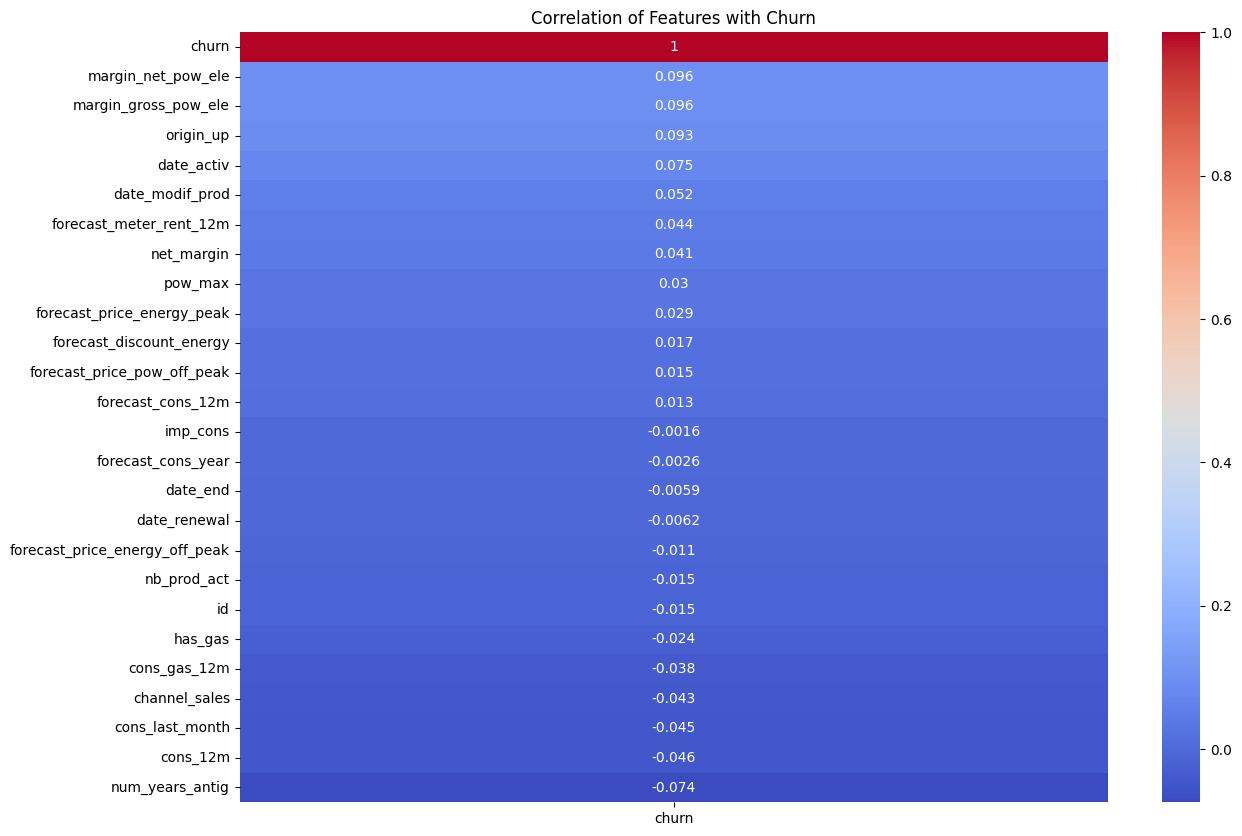

In [11]:

# Correlation Heatmap with churn
correlation = customer_df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation[['churn']].sort_values(by='churn', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation of Features with Churn")
plt.show()
    

In [12]:

# Prepare features and labels
X = customer_df.drop(columns=['churn', 'id'])
y = customer_df['churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    

In [13]:

# Drop datetime columns from X_train and X_test
X_train_cleaned = X_train.drop(columns=['date_activ', 'date_end', 'date_modif_prod', 'date_renewal'])
X_test_cleaned = X_test.drop(columns=['date_activ', 'date_end', 'date_modif_prod', 'date_renewal'])

# Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_cleaned, y_train)
    

RandomForestClassifier(random_state=42)

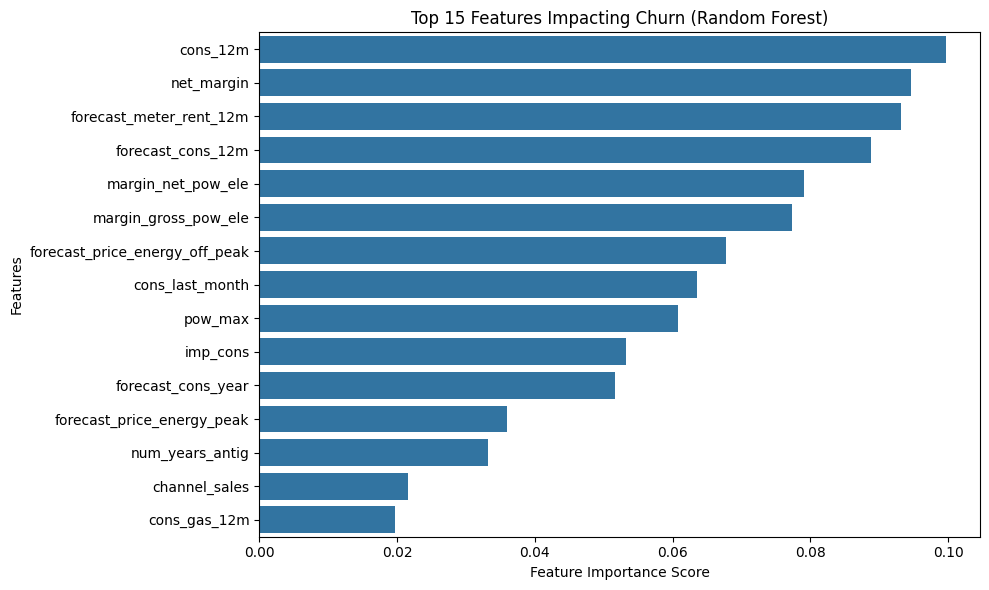

In [14]:

# Feature Importance Plot
importances = pd.Series(rf.feature_importances_, index=X_train_cleaned.columns).sort_values(ascending=False)
top_features = importances[:15]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top 15 Features Impacting Churn (Random Forest)")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
    

In [15]:

# Model Evaluation
y_pred = rf.predict(X_test_cleaned)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
    

Confusion Matrix:
[[2613    4]
 [ 292   13]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95      2617
         1.0       0.76      0.04      0.08       305

    accuracy                           0.90      2922
   macro avg       0.83      0.52      0.51      2922
weighted avg       0.89      0.90      0.86      2922

